In [2]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import XLNetTokenizer
from sklearn.metrics import confusion_matrix, classification_report
import sys
import os
import torch.nn.functional as F # Für Softmax/Confidence

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.dataset import get_datasets, EVASION_MAP_9, EVASION_MAP_5, CLARITY_MAP, resolve_evasion_vote, TAXONOMY_PARENTS
from src.model import SingleHeadXLNet
# Import Baselines function
from src.baseline_models import run_baselines

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
CLARITY_NAMES = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

print(f"Using device: {DEVICE}")

# --- MAPPINGS ---
# K=9 Logic (Standard):
# 0:Exp->0, 1:Dod->1, 2:Imp->1, 3:Gen->1, 4:Def->1, 
# 5:Decl->2, 6:Ign->2, 7:Clar->2, 8:Part->1
MAPPING_K9 = np.array([0, 1, 1, 1, 1, 2, 2, 2, 1])

# K=5 Logic (Parent Consistency):
# 0: Explicit -> 0 (Clear Reply)
# 1: Active (Dodging/Deflection) -> 1 (Ambivalent)
# 2: Vague (Implicit/General/Partial) -> 1 (Ambivalent)
# 3: Refusal (Declining/Ignorance) -> 2 (Clear Non-Reply)
# 4: Clarification -> 2 (Clear Non-Reply)
MAPPING_K5 = np.array([0, 1, 1, 2, 2])

print("Mappings defined.")

Using device: cpu
Mappings defined.


In [5]:
print("--- Loading XLNet Models & Data ---")

# 1. Load Tokenizer
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

# 2. Load Datasets
# Wir nutzen get_datasets, um die korrekten Input-Formate zu garantieren
_, test_ds_direct, _, _ = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='clarity')
_, test_ds_hier, _, _ = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='evasion_9')
_, test_ds_red, _, _ = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='evasion_5')

loaders = {
    "XLNet (Direct)": DataLoader(test_ds_direct, batch_size=BATCH_SIZE),
    "XLNet (Hierarchical)": DataLoader(test_ds_hier, batch_size=BATCH_SIZE),
    "XLNet (Reduced)": DataLoader(test_ds_red, batch_size=BATCH_SIZE)
}

# 3. Init Models & Load Weights
models = {
    "XLNet (Direct)": SingleHeadXLNet(num_labels=3).to(DEVICE),
    "XLNet (Hierarchical)": SingleHeadXLNet(num_labels=9).to(DEVICE),
    "XLNet (Reduced)": SingleHeadXLNet(num_labels=5).to(DEVICE)
}

try:
    models["XLNet (Direct)"].load_state_dict(torch.load('../models/xlnet_direct_clarity.pt', map_location=DEVICE))
    models["XLNet (Hierarchical)"].load_state_dict(torch.load('../models/xlnet_hierarchical_k9.pt', map_location=DEVICE))
    models["XLNet (Reduced)"].load_state_dict(torch.load('../models/xlnet_reduced_k5.pt', map_location=DEVICE))
    print("XLNet Models loaded successfully.")
except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Could not load models. Check paths! {e}")

--- Loading XLNet Models & Data ---
--- Loading Datasets (Mode: clarity) ---
Applying Democratic Voting Logic...
Train size: 3448 | Test size: 308
--- Loading Datasets (Mode: evasion_9) ---
Applying Democratic Voting Logic...
Train size: 3448 | Test size: 308
--- Loading Datasets (Mode: evasion_5) ---
Applying Democratic Voting Logic...
Train size: 3448 | Test size: 308
loading xlnet-base-cased with 3 labels...
loading xlnet-base-cased with 9 labels...
loading xlnet-base-cased with 5 labels...
XLNet Models loaded successfully.


In [6]:
results = {}

def get_predictions(model_name):
    model = models[model_name]
    loader = loaders[model_name]
    model.eval()
    
    preds_raw = []
    trues_clarity = []
    confidences = [] # Für Bonus-Plot
    
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            
            # Forward Pass
            logits = model(ids, mask)
            
            # Get Probabilities (Confidence)
            probs = F.softmax(logits, dim=1)
            max_probs, argmax_preds = torch.max(probs, dim=1)
            
            preds_raw.extend(argmax_preds.cpu().numpy())
            confidences.extend(max_probs.cpu().numpy())
            trues_clarity.extend(batch['clarity_truth'].numpy())
            
    preds_raw = np.array(preds_raw)
    trues_clarity = np.array(trues_clarity)
    confidences = np.array(confidences)
    
    # Apply Mapping to get Clarity Labels
    if "Direct" in model_name:
        preds_final = preds_raw
    elif "Hierarchical" in model_name:
        preds_final = MAPPING_K9[preds_raw]
    elif "Reduced" in model_name:
        preds_final = MAPPING_K5[preds_raw]
        
    return trues_clarity, preds_final, confidences

# Collect XLNet Results
for name in models.keys():
    print(f"Predicting {name}...")
    y_true, y_pred, confs = get_predictions(name)
    results[name] = {"y_true": y_true, "y_pred": y_pred, "conf": confs}

Predicting XLNet (Direct)...
Predicting XLNet (Hierarchical)...
Predicting XLNet (Reduced)...


In [7]:
print("--- Running Baselines (via src.baseline_models) ---")

# 1. Run Logistic Regression Training & Inference
baseline_out = run_baselines('../data/raw/train.csv', '../data/raw/test.csv')

# 2. Integrate into 'results' dictionary
for method_name, data in baseline_out.items():
    # Convert String Labels ("Ambivalent") to IDs (1) for consistent plotting
    y_true_ids = np.array([CLARITY_MAP.get(s, 1) for s in data['y_true']])
    y_pred_ids = np.array([CLARITY_MAP.get(s, 1) for s in data['y_pred']])
    
    results[f"Baseline ({method_name})"] = {
        "y_true": y_true_ids, 
        "y_pred": y_pred_ids,
        "conf": None # LogReg Confidence lassen wir hier weg
    }

print("Baselines integrated.")

--- Running Baselines (via src.baseline_models) ---
--- Running Baselines (Train: ../data/raw/train.csv) ---
Training Direct Logistic Regression...


/Users/imad.azizi/Desktop/NLPGroup29/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training Hierarchical Logistic Regression...


/Users/imad.azizi/Desktop/NLPGroup29/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Baselines integrated.


<Figure size 2000x1200 with 0 Axes>

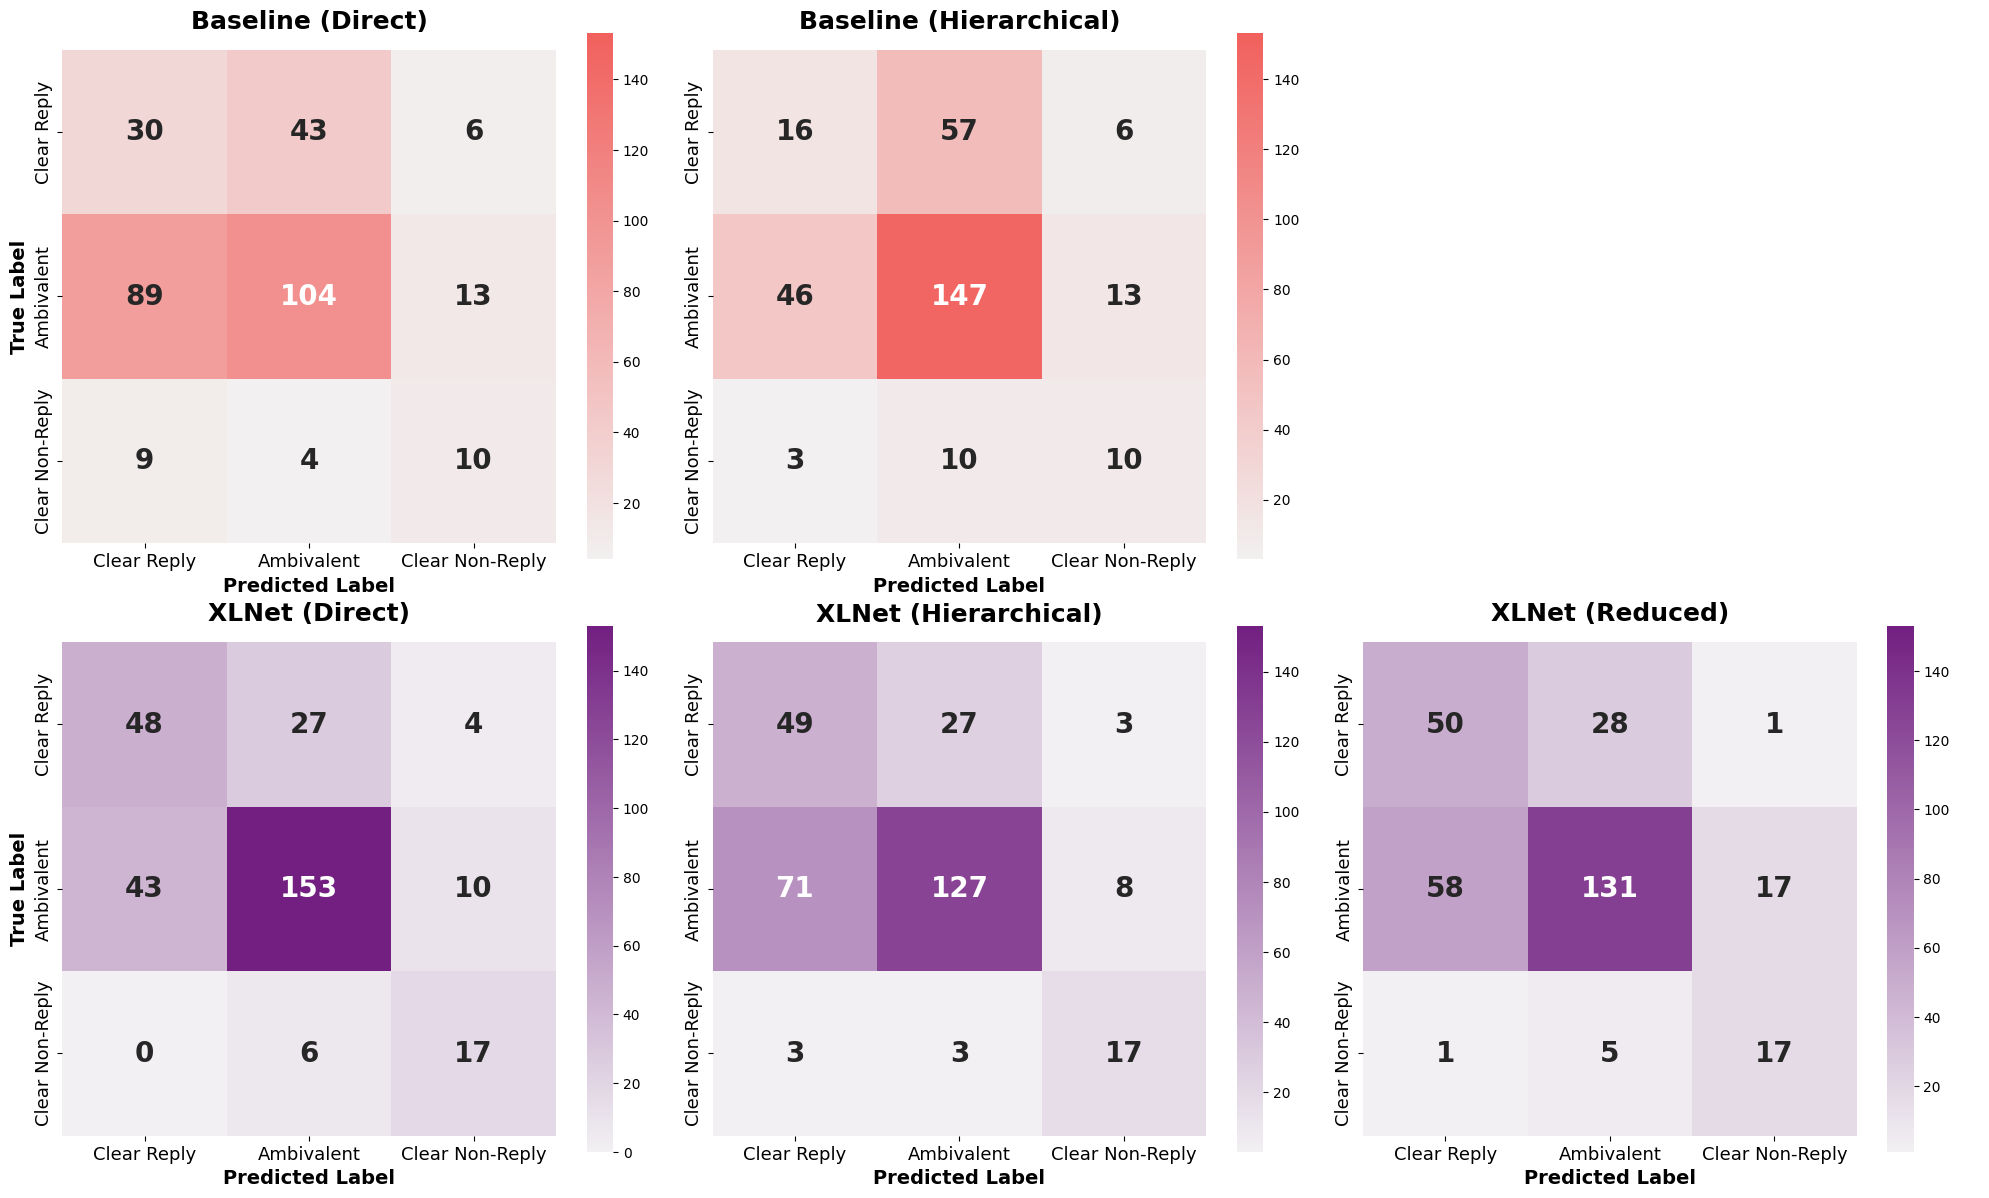

In [31]:
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns


# Plot-Konfiguration
plt.figure(figsize=(20, 12)) 
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3) 

# Layout Mapping
layout_mapping = {
    "Baseline (Direct)": (0, 0),
    "Baseline (Hierarchical)": (0, 1),
    "XLNet (Direct)": (1, 0),
    "XLNet (Hierarchical)": (1, 1),
    "XLNet (Reduced)": (1, 2)
}

# Den leeren Plot oben rechts ausschalten
axes[0, 2].axis('off')

# Globales Maximum finden für einheitliche Farbskala
all_matrices = []
for name in layout_mapping.keys():
    if name in results:
        cm = confusion_matrix(results[name]['y_true'], results[name]['y_pred'])
        all_matrices.append(cm)
vmax_val = np.max(all_matrices) if all_matrices else None

# Plotten
for name, pos in layout_mapping.items():
    row, col = pos
    ax = axes[row, col]
    
    if name not in results:
        ax.axis('off')
        continue
        
    data = results[name]
    cm = confusion_matrix(data['y_true'], data['y_pred'])
    
    colors = sns.color_palette("magma", n_colors=2)
    COLOR_XLNET    = colors[0]
    COLOR_BASELINE = colors[1]


    cmap = cmap_xlnet if 'XLNet' in name else cmap_baseline


    # 2) Daraus zwei Colormaps bauen (weiß -> jeweilige Farbe)
    cmap_baseline = sns.light_palette(COLOR_BASELINE, as_cmap=True)
    cmap_xlnet    = sns.light_palette(COLOR_XLNET, as_cmap=True)
    
    # --- ÄNDERUNG: Schriftgrößen erhöht ---
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, 
                xticklabels=CLARITY_NAMES, yticklabels=CLARITY_NAMES, 
                cbar=True, vmax=vmax_val, square=True,
                annot_kws={"size": 20, "weight": "bold"}) # Zahlen jetzt GRÖSSER (16)
    
    ax.set_title(name, fontsize=18, weight='bold', pad=15) # Titel größer (18)
    ax.set_xlabel('Predicted Label', fontsize=14, weight='bold') # Label größer (14)
    
    # Tick-Labels (Klassennamen) größer machen
    ax.tick_params(axis='both', which='major', labelsize=13)

    if col == 0:
        ax.set_ylabel('True Label', fontsize=14, weight='bold') # Label größer (14)
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()
# plt.savefig('plots/confusion_matrices_split.png')

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix

def row_rate(cm, true_idx, pred_idx):
    row_sum = cm[true_idx].sum()
    return 100.0 * cm[true_idx, pred_idx] / row_sum if row_sum else np.nan

label_to_idx = {name: i for i, name in enumerate(CLARITY_NAMES)}

pairs = [
    ("Clear Reply", "Ambivalent"),
    ("Ambivalent", "Clear Reply"),
    ("Clear Non-Reply", "Ambivalent"),
]

for name in layout_mapping.keys():
    if name not in results:
        continue
    y_true = results[name]['y_true']
    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_true, y_pred)

    print("\n", name)
    for t, p in pairs:
        r = row_rate(cm, label_to_idx[t], label_to_idx[p])
        print(f"  P(pred={p} | true={t}) = {r:.1f}%  ({cm[label_to_idx[t], label_to_idx[p]]}/{cm[label_to_idx[t]].sum()})")



 Baseline (Direct)
  P(pred=Ambivalent | true=Clear Reply) = 54.4%  (43/79)
  P(pred=Clear Reply | true=Ambivalent) = 43.2%  (89/206)
  P(pred=Ambivalent | true=Clear Non-Reply) = 17.4%  (4/23)

 Baseline (Hierarchical)
  P(pred=Ambivalent | true=Clear Reply) = 72.2%  (57/79)
  P(pred=Clear Reply | true=Ambivalent) = 22.3%  (46/206)
  P(pred=Ambivalent | true=Clear Non-Reply) = 43.5%  (10/23)

 XLNet (Direct)
  P(pred=Ambivalent | true=Clear Reply) = 34.2%  (27/79)
  P(pred=Clear Reply | true=Ambivalent) = 20.9%  (43/206)
  P(pred=Ambivalent | true=Clear Non-Reply) = 26.1%  (6/23)

 XLNet (Hierarchical)
  P(pred=Ambivalent | true=Clear Reply) = 34.2%  (27/79)
  P(pred=Clear Reply | true=Ambivalent) = 34.5%  (71/206)
  P(pred=Ambivalent | true=Clear Non-Reply) = 13.0%  (3/23)

 XLNet (Reduced)
  P(pred=Ambivalent | true=Clear Reply) = 35.4%  (28/79)
  P(pred=Clear Reply | true=Ambivalent) = 28.2%  (58/206)
  P(pred=Ambivalent | true=Clear Non-Reply) = 21.7%  (5/23)


In [18]:
metrics_list = []

for name, data in results.items():
    report = classification_report(data['y_true'], data['y_pred'], target_names=CLARITY_NAMES, output_dict=True)
    metrics_list.append({
        "Model": name,
        "Macro F1": report['macro avg']['f1-score'],
        "Accuracy": report['accuracy'],
        "F1 (Ambivalent)": report['Ambivalent']['f1-score'],
        "F1 (Clear Reply)": report['Clear Reply']['f1-score'],
        "F1 (Non-Reply)": report['Clear Non-Reply']['f1-score']
    })

df_res = pd.DataFrame(metrics_list).sort_values("Macro F1", ascending=False)
print("=== Final Results Table ===")
display(df_res)

=== Final Results Table ===


,Model,Macro F1,Accuracy,F1 (Ambivalent),F1 (Clear Reply),F1 (Non-Reply)
0,XLNet (Direct),0.658316,0.707792,0.780612,0.564706,0.629630
1,XLNet (Hierarchical),0.617180,0.626623,0.699725,0.485149,0.666667
2,XLNet (Reduced),0.608743,0.642857,0.708108,0.531915,0.586207
4,Baseline (Hierarchical),0.435613,0.561688,0.700000,0.222222,0.384615
3,Baseline (Direct),0.419035,0.467532,0.582633,0.289855,0.384615


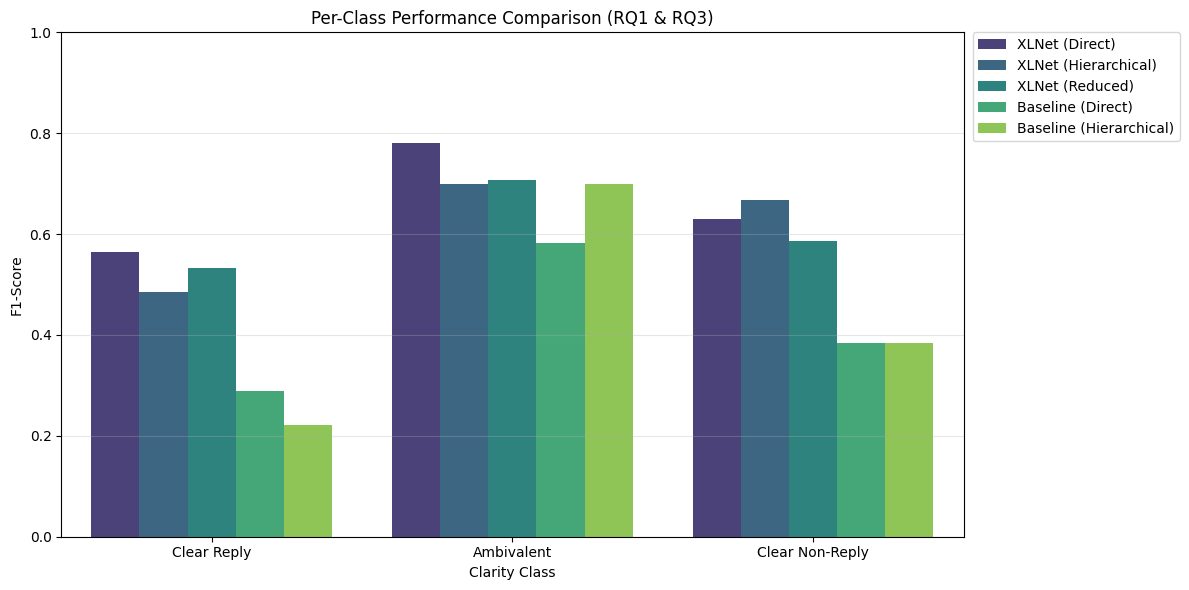

Interpretation:
- Ambivalent ist meist die stärkste Klasse (da am häufigsten).
- Achte darauf, ob 'XLNet (Hierarchical)' oder 'Reduced' bei 'Clear Non-Reply' besser abschneidet als 'Direct'.


In [19]:
# --- PLOT: Per-Class Performance Comparison ---

# Wir bauen die Daten direkt frisch aus den 'results' auf, 
# anstatt zu versuchen, die Spaltennamen von df_res zu erraten.
plot_data_clean = []

for name, data in results.items():
    # Berechne den Report nochmal frisch für dieses Modell
    report = classification_report(data['y_true'], data['y_pred'], target_names=CLARITY_NAMES, output_dict=True)
    
    for cls in CLARITY_NAMES:
        plot_data_clean.append({
            "Model": name,
            "Class": cls,
            "F1-Score": report[cls]['f1-score']
        })

df_plot_class = pd.DataFrame(plot_data_clean)

# Plotten
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot_class, x="Class", y="F1-Score", hue="Model", palette="viridis")
plt.title("Per-Class Performance Comparison (RQ1 & RQ3)")
plt.ylim(0, 1.0)
plt.ylabel("F1-Score")
plt.xlabel("Clarity Class")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Ambivalent ist meist die stärkste Klasse (da am häufigsten).")
print("- Achte darauf, ob 'XLNet (Hierarchical)' oder 'Reduced' bei 'Clear Non-Reply' besser abschneidet als 'Direct'.")

<Figure size 1000x600 with 0 Axes>

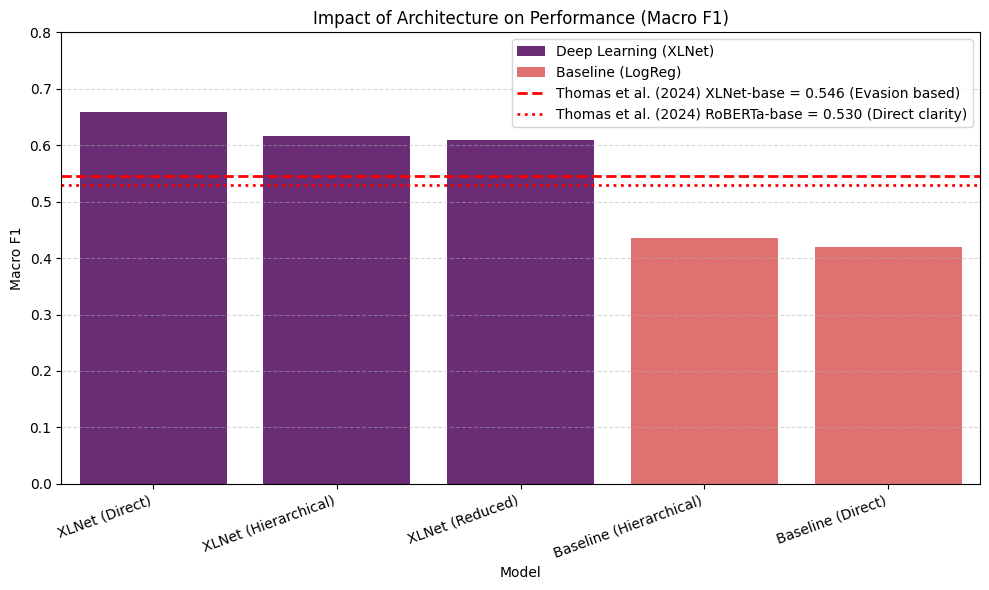

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

BENCH_XLNET_BASE = 0.546
BENCH_ROBERTA_BASE = 0.530

df_res["Type"] = df_res["Model"].apply(
    lambda x: "Deep Learning (XLNet)" if "XLNet" in x else "Baseline (LogReg)"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_res, x="Model", y="Macro F1",
    hue="Type", dodge=False, palette="magma"
)

ax.set_title("Impact of Architecture on Performance (Macro F1)")
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 0.8)
plt.xticks(rotation=20, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.axhline(
    BENCH_XLNET_BASE, color="red", linestyle="--", linewidth=2,
    label=f"Thomas et al. (2024) XLNet-base = {BENCH_XLNET_BASE:.3f} (Evasion based)"
)
ax.axhline(
    BENCH_ROBERTA_BASE, color="red", linestyle=":", linewidth=2,
    label=f"Thomas et al. (2024) RoBERTa-base = {BENCH_ROBERTA_BASE:.3f} (Direct clarity)"
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


In [ ]:
print("\n=== QUALITATIVE ERROR ANALYSIS ===")

# Load Raw Text properly
df_test_raw = pd.read_csv('../data/raw/test.csv').fillna("")
test_texts = df_test_raw['interview_answer'].tolist()
test_questions = df_test_raw['question'].tolist()

# Compare: XLNet Direct vs XLNet Hierarchical
y_pred_dir = results["XLNet (Direct)"]["y_pred"]
y_pred_hier = results["XLNet (Hierarchical)"]["y_pred"]
y_true = results["XLNet (Direct)"]["y_true"]

hits = 0
print("--- Examples: Hierarchical Correct vs. Direct Wrong ---")
for i in range(len(test_texts)):
    if hits >= 3: break
    
    if y_pred_hier[i] == y_true[i] and y_pred_dir[i] != y_true[i]:
        print(f"\n[Example {i}]")
        print(f"Q: {str(test_questions[i])}")
        print(f"A: {str(test_texts[i])[:150]}...")
        print(f"True Label:   {CLARITY_NAMES[y_true[i]]}")
        print(f"Hierarchical: {CLARITY_NAMES[y_pred_hier[i]]} (CORRECT)")
        print(f"Direct:       {CLARITY_NAMES[y_pred_dir[i]]} (WRONG)")
        hits += 1


=== QUALITATIVE ERROR ANALYSIS ===
--- Examples: Hierarchical Correct vs. Direct Wrong ---

[Example 19]
Q: What makes this more than a piece of paper if you don't have the will of the international community to back it up?
A: Yes. No, listen—all the more reason why we need to help our friends and allies get the forces necessary to help the Lebanese forces keep the cessation...
True Label:   Ambivalent
Hierarchical: Ambivalent (CORRECT)
Direct:       Clear Reply (WRONG)

[Example 53]
Q: What is the magnet?
A: Yes, I would hope it would be international pressure on not only Hizballah, the group of Hizballah within Lebanon, but also its sponsors. And that's t...
True Label:   Ambivalent
Hierarchical: Ambivalent (CORRECT)
Direct:       Clear Reply (WRONG)

[Example 56]
Q:  Why wouldn't you be frustrated, sir, about what's happening?
A: I'm not—I do remember the meeting; I don't remember being surprised. I'm not sure what they meant by that....
True Label:   Clear Non-Reply
Hierarchical: 


--- Bonus 1: Annotator Agreement ---


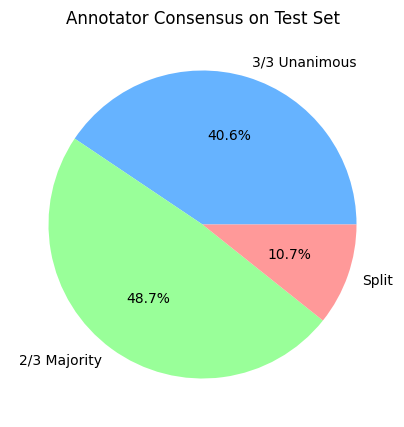


--- Bonus 2: Answer Length by Evasion Strategy ---


/var/folders/qt/6mwych9n1yd7rn12mtxs4svr0000gp/T/ipykernel_55550/3477191962.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_data, x='evasion_label', y='word_count', order=order, palette="Set3")


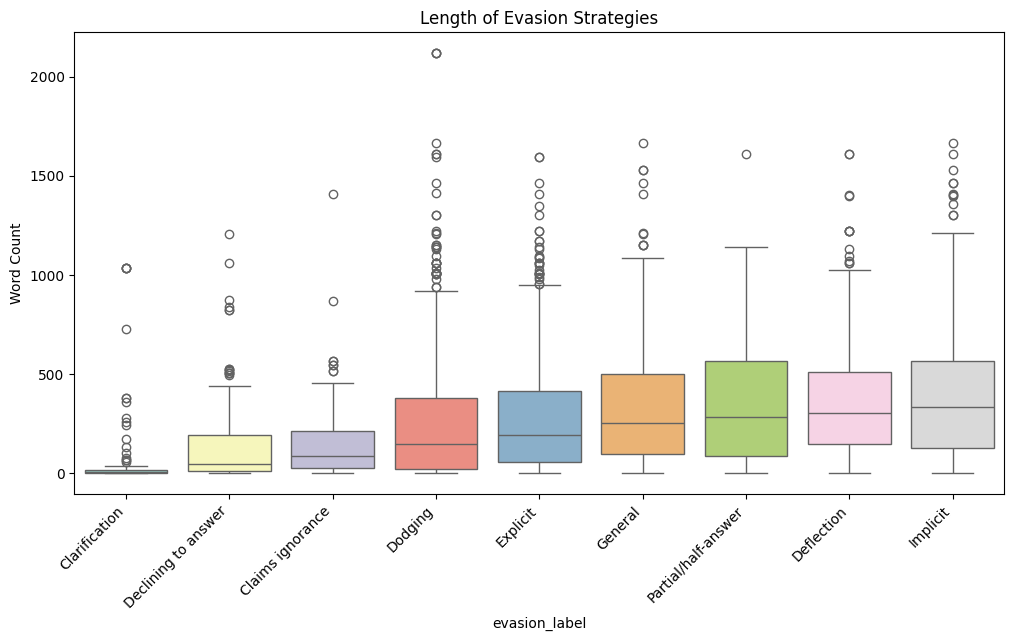


--- Bonus 3: Model Confidence (XLNet Direct) ---


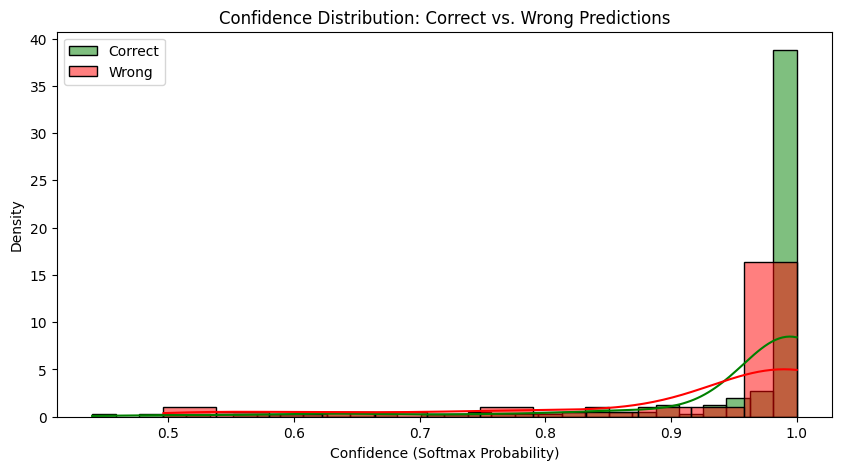

In [12]:
# 1. Annotator Agreement (Pie Chart)
print("\n--- Bonus 1: Annotator Agreement ---")
stats = {"3/3 Unanimous": 0, "2/3 Majority": 0, "Split": 0}
for i, row in df_test_raw.iterrows():
    votes = [str(row.get(f'annotator{n}','')).strip() for n in range(1,4) if row.get(f'annotator{n}')]
    if not votes: continue
    counts = pd.Series(votes).value_counts()
    if counts.iloc[0] == 3: stats["3/3 Unanimous"] += 1
    elif counts.iloc[0] == 2: stats["2/3 Majority"] += 1
    else: stats["Split"] += 1

plt.figure(figsize=(5, 5))
plt.pie(stats.values(), labels=stats.keys(), autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title("Annotator Consensus on Test Set")
plt.show()

# 2. Length Analysis (Boxplot)
print("\n--- Bonus 2: Answer Length by Evasion Strategy ---")
df_train = pd.read_csv('../data/raw/train.csv')
df_train['word_count'] = df_train['interview_answer'].apply(lambda x: len(str(x).split()))
valid_data = df_train[df_train['evasion_label'].isin(EVASION_MAP_9.keys())]
# Sort by median length
order = valid_data.groupby('evasion_label')['word_count'].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(data=valid_data, x='evasion_label', y='word_count', order=order, palette="Set3")
plt.xticks(rotation=45, ha="right")
plt.title("Length of Evasion Strategies")
plt.ylabel("Word Count")
plt.show()

# 3. Model Confidence (Histogram)
print("\n--- Bonus 3: Model Confidence (XLNet Direct) ---")
# Wir nutzen die gespeicherten Confidences
confs = results["XLNet (Direct)"]["conf"]
preds = results["XLNet (Direct)"]["y_pred"]
trues = results["XLNet (Direct)"]["y_true"]

correct_confs = confs[preds == trues]
wrong_confs = confs[preds != trues]

plt.figure(figsize=(10, 5))
sns.histplot(correct_confs, color="green", label="Correct", kde=True, stat="density", alpha=0.5)
sns.histplot(wrong_confs, color="red", label="Wrong", kde=True, stat="density", alpha=0.5)
plt.title("Confidence Distribution: Correct vs. Wrong Predictions")
plt.xlabel("Confidence (Softmax Probability)")
plt.legend()
plt.show()

In [13]:
print("\n=== BLOCK 11: Comprehensive Metrics Table (Paper-Ready) ===")

detailed_metrics = []

for name, data in results.items():
    # Berechne den vollen Report
    report = classification_report(data['y_true'], data['y_pred'], target_names=CLARITY_NAMES, output_dict=True)
    
    # Basis-Metriken
    entry = {
        "Model": name,
        "Accuracy": report['accuracy'],
        "Macro F1": report['macro avg']['f1-score'],
        "Macro Prec": report['macro avg']['precision'],
        "Macro Rec": report['macro avg']['recall'],
        "Wt. F1": report['weighted avg']['f1-score'] # Weighted F1 (gut bei Imbalance)
    }
    
    # Pro Klasse Details hinzufügen (Flattening)
    for cls in CLARITY_NAMES:
        short_cls = cls.replace("Clear ", "")
        entry[f"{short_cls} P"] = report[cls]['precision']
        entry[f"{short_cls} R"] = report[cls]['recall']
        entry[f"{short_cls} F1"] = report[cls]['f1-score']
        
    detailed_metrics.append(entry)

df_detailed = pd.DataFrame(detailed_metrics).set_index("Model")

# Sortieren nach Macro F1
df_detailed = df_detailed.sort_values("Macro F1", ascending=False)

print("Legende: P = Precision, R = Recall, Wt. = Weighted Average")
# Style die Tabelle für bessere Lesbarkeit (funktioniert in Jupyter)
# (Färbt hohe Werte grün, niedrige rot)
display(df_detailed.style.background_gradient(cmap='RdYlGn', subset=['Macro F1', 'Accuracy', 'Wt. F1', 'Ambivalent F1', 'Reply F1', 'Non-Reply F1'])
       .format("{:.3f}"))


=== BLOCK 11: Comprehensive Metrics Table (Paper-Ready) ===
Legende: P = Precision, R = Recall, Wt. = Weighted Average


,Accuracy,Macro F1,Macro Prec,Macro Rec,Wt. F1,Reply P,Reply R,Reply F1,Ambivalent P,Ambivalent R,Ambivalent F1,Non-Reply P,Non-Reply R,Non-Reply F1
Model,,,,,,,,,,,,,,
XLNet (Direct),0.708,0.658,0.633,0.696,0.714,0.527,0.608,0.565,0.823,0.743,0.781,0.548,0.739,0.630
XLNet (Hierarchical),0.627,0.617,0.605,0.659,0.642,0.398,0.620,0.485,0.809,0.617,0.700,0.607,0.739,0.667
XLNet (Reduced),0.643,0.609,0.581,0.669,0.654,0.459,0.633,0.532,0.799,0.636,0.708,0.486,0.739,0.586
Baseline (Hierarchical),0.562,0.436,0.426,0.450,0.554,0.246,0.203,0.222,0.687,0.714,0.700,0.345,0.435,0.385
Baseline (Direct),0.468,0.419,0.423,0.440,0.493,0.234,0.380,0.290,0.689,0.505,0.583,0.345,0.435,0.385



=== BLOCK 12: Clarity Detection Performance by Underlying Evasion Strategy ===


/var/folders/qt/6mwych9n1yd7rn12mtxs4svr0000gp/T/ipykernel_33211/3239369713.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


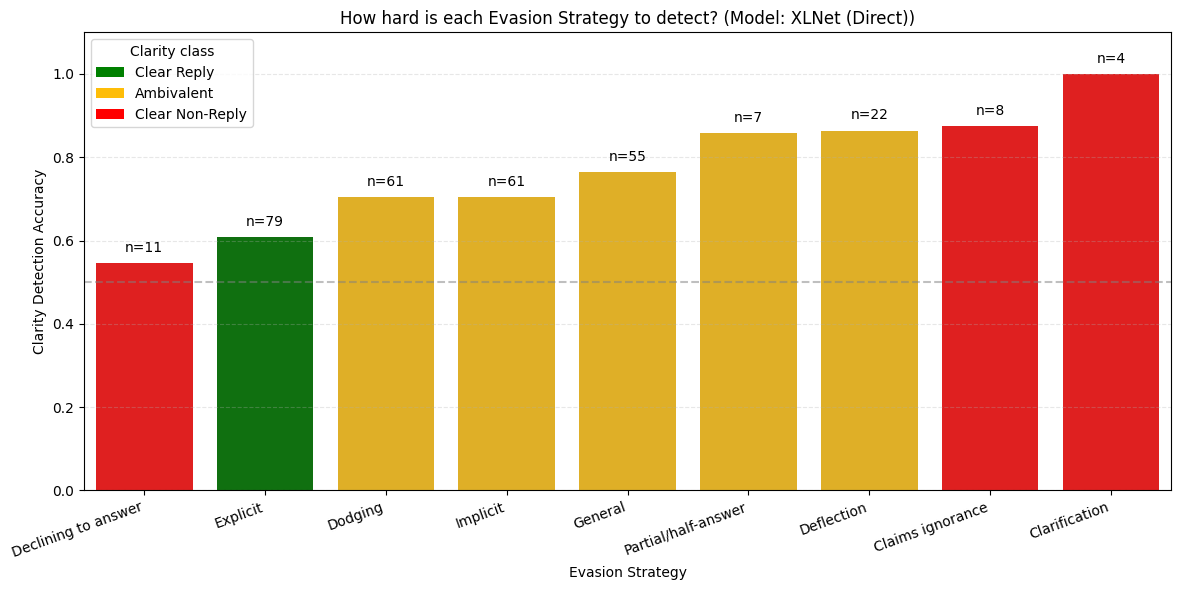

Interpretation:
- Balken links: schwierigere Evasion-Strategien (niedrige Accuracy).
- Balken rechts: leichtere Evasion-Strategien (hohe Accuracy).


In [ ]:
print("\n=== BLOCK 12: Clarity Detection Performance by Underlying Evasion Strategy ===")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# --- Colors / Mapping (wie von dir gewünscht) ---
CLARITY_COLORS = {
    "Clear Reply": "green",
    "Ambivalent": "#febd08",
    "Clear Non-Reply": "red",
}

EVASION_TO_CLARITY = {
    "Explicit": "Clear Reply",
    "Implicit": "Ambivalent",
    "General": "Ambivalent",
    "Dodging": "Ambivalent",
    "Deflection": "Ambivalent",
    "Partial/half-answer": "Ambivalent",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Clear Non-Reply",  # so wie du es willst
}

CLARITY_ORDER = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

# --- Load test + voting ---
df_test_raw = pd.read_csv("../data/raw/test.csv").fillna("")
df_test_raw["voted_evasion"] = df_test_raw.apply(lambda r: resolve_evasion_vote(r), axis=1)

# --- Select model ---
best_model_name = "XLNet (Direct)"
y_pred = results[best_model_name]["y_pred"]
y_true = results[best_model_name]["y_true"]

# Sicherheitscheck: gleiche Länge
df_test_raw = df_test_raw.reset_index(drop=True)
if len(df_test_raw) != len(y_true) or len(y_true) != len(y_pred):
    raise ValueError(
        f"Length mismatch: len(test)={len(df_test_raw)}, len(y_true)={len(y_true)}, len(y_pred)={len(y_pred)}"
    )

# --- Build analysis table (index-sicher mit enumerate) ---
analysis_rows = []
for i, ev_label in enumerate(df_test_raw["voted_evasion"].tolist()):
    if ev_label not in EVASION_TO_CLARITY:
        continue

    analysis_rows.append({
        "Evasion Strategy": ev_label,
        "Clarity Class": EVASION_TO_CLARITY[ev_label],
        "Correct": int(y_pred[i] == y_true[i]),
    })

df_analysis = pd.DataFrame(analysis_rows)

# --- Aggregate: accuracy + sample count per evasion strategy ---
df_grouped = (
    df_analysis
    .groupby(["Evasion Strategy", "Clarity Class"], as_index=False)
    .agg(Accuracy=("Correct", "mean"), Count=("Correct", "size"))
    .sort_values("Accuracy", ascending=True)  # schwerste zuerst
)

# Farb-Liste in exakt derselben Reihenfolge wie df_grouped
bar_colors = df_grouped["Clarity Class"].map(CLARITY_COLORS).tolist()

# --- Plot ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_grouped,
    x="Evasion Strategy",
    y="Accuracy",
    order=df_grouped["Evasion Strategy"].tolist(),
    palette=bar_colors
)

# Counts annotieren (1:1 zip -> kein IndexError)
for p, count in zip(ax.patches, df_grouped["Count"].tolist()):
    ax.annotate(
        f"n={count}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom",
        xytext=(0, 6),
        textcoords="offset points"
    )

# Legend manuell (weil wir kein hue nutzen)
legend_handles = [
    Patch(facecolor=CLARITY_COLORS[c], label=c)
    for c in CLARITY_ORDER
    if c in set(df_grouped["Clarity Class"])
]
ax.legend(handles=legend_handles, title="Clarity class", loc="upper left", frameon=True)

ax.set_title(f"How hard is each Evasion Strategy to detect? (Model: {best_model_name})")
ax.set_ylabel("Clarity Detection Accuracy")
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Balken links: schwierigere Evasion-Strategien (niedrige Accuracy).")
print("- Balken rechts: leichtere Evasion-Strategien (hohe Accuracy).")


In [15]:
print("\n=== BLOCK 13: The 'Hardest' Samples (Intersection of Failures) ===")

# 1. Identifiziere Indizes, wo ALLE Modelle falsch lagen
df_test_raw = pd.read_csv('../data/raw/test.csv').fillna("")
n_samples = len(df_test_raw)
failed_indices = set(range(n_samples)) # Start mit allen

model_names_to_check = ["Baseline (Direct)", "XLNet (Direct)", "XLNet (Hierarchical)"]

for name in model_names_to_check:
    if name not in results: continue
    y_true = results[name]["y_true"]
    y_pred = results[name]["y_pred"]
    
    # Finde Indizes, wo dieses Modell RICHTIG lag
    correct_indices = {i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t == p}
    
    # Entferne diese aus der Menge der "Failed Indices"
    # Übrig bleiben die, die von KEINEM Modell gelöst wurden
    failed_indices = failed_indices - correct_indices

failed_indices = list(failed_indices)
print(f"Number of samples that NO model could solve: {len(failed_indices)} out of {n_samples}")

# 2. Zeige Beispiele
print("\n--- Examples of 'Impossible' Questions ---")
for idx in failed_indices[:5]: # Zeige 5
    row = df_test_raw.iloc[idx]
    q = row['question']
    a = row['interview_answer']
    true_label = CLARITY_NAMES[CLARITY_MAP.get(row['clarity_label'], 1)]
    
    print(f"\n[ID {idx}] True Label: {true_label}")
    print(f"Q: {q}")
    print(f"A: {str(a)[:200]}...")
    
    # Zeige was die Modelle stattdessen geraten haben
    preds_str = []
    for name in model_names_to_check:
        pred_id = results[name]["y_pred"][idx]
        preds_str.append(f"{name}: {CLARITY_NAMES[pred_id]}")
    print("Predictions: " + " | ".join(preds_str))


=== BLOCK 13: The 'Hardest' Samples (Intersection of Failures) ===
Number of samples that NO model could solve: 47 out of 308

--- Examples of 'Impossible' Questions ---

[ID 257] True Label: Clear Reply
Q: Contrast the impact on the economy if Republicans retain control of Congress versus what happens if Democrats take over.
A: If I weren't here—first of all, I don't believe the Democrats are going to take over, because our record on the economy is strong. If the American people would take a step back and realize how effecti...
Predictions: Baseline (Direct): Ambivalent | XLNet (Direct): Ambivalent | XLNet (Hierarchical): Ambivalent

[ID 260] True Label: Clear Reply
Q: The question Q is asking if the person being addressed voted in the Texas primary.
A: I did, and I'm not telling you who. [] Thank you....
Predictions: Baseline (Direct): Clear Non-Reply | XLNet (Direct): Clear Non-Reply | XLNet (Hierarchical): Clear Non-Reply

[ID 135] True Label: Ambivalent
Q: What is the President's

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix

print("=== DETAILED ERROR ANALYSIS (Confusion Matrix Percentages) ===")

# Wir schauen uns nur die wichtigsten Modelle an
models_to_analyze = ["XLNet (Direct)", "XLNet (Hierarchical)", "Baseline (Hierarchical)"]

for name in models_to_analyze:
    if name not in results: continue
    
    print(f"\nModel: {name}")
    y_true = results[name]['y_true']
    y_pred = results[name]['y_pred']
    
    # Erstelle Matrix (Zeilen = True, Spalten = Pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2]) # 0=Reply, 1=Ambivalent, 2=Non-Reply
    
    # Berechne Prozentzahlen pro Zeile (True Label)
    # Wie viel Prozent der wahren "Clear Replies" wurden als was vorhergesagt?
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    print(f"{'True Label':<20} | {'Pred: Reply':<12} | {'Pred: Ambiv':<12} | {'Pred: Non-Rep':<12}")
    print("-" * 65)
    
    labels = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
    for i, label in enumerate(labels):
        print(f"{label:<20} | {cm_norm[i,0]:6.1f}%      | {cm_norm[i,1]:6.1f}%      | {cm_norm[i,2]:6.1f}%")

print("\n============================================================")

=== DETAILED ERROR ANALYSIS (Confusion Matrix Percentages) ===

Model: XLNet (Direct)
True Label           | Pred: Reply  | Pred: Ambiv  | Pred: Non-Rep
-----------------------------------------------------------------
Clear Reply          |   60.8%      |   34.2%      |    5.1%
Ambivalent           |   20.9%      |   74.3%      |    4.9%
Clear Non-Reply      |    0.0%      |   26.1%      |   73.9%

Model: XLNet (Hierarchical)
True Label           | Pred: Reply  | Pred: Ambiv  | Pred: Non-Rep
-----------------------------------------------------------------
Clear Reply          |   62.0%      |   34.2%      |    3.8%
Ambivalent           |   34.5%      |   61.7%      |    3.9%
Clear Non-Reply      |   13.0%      |   13.0%      |   73.9%

Model: Baseline (Hierarchical)
True Label           | Pred: Reply  | Pred: Ambiv  | Pred: Non-Rep
-----------------------------------------------------------------
Clear Reply          |   20.3%      |   72.2%      |    7.6%
Ambivalent           |   22

=== IMPROVED DIFFICULTY ANALYSIS (Model: XLNet Hierarchical) ===
Analysis based on Model: XLNet (Hierarchical)
   Evasion Strategy   Clarity Class  Accuracy  Count
Declining to answer Clear Non-Reply  0.545455     11
            General      Ambivalent  0.563636     55
Partial/half-answer      Ambivalent  0.571429      7
            Dodging      Ambivalent  0.590164     61
           Explicit     Clear Reply  0.620253     79
           Implicit      Ambivalent  0.639344     61
         Deflection      Ambivalent  0.772727     22
   Claims ignorance Clear Non-Reply  0.875000      8
      Clarification Clear Non-Reply  1.000000      4


/var/folders/qt/6mwych9n1yd7rn12mtxs4svr0000gp/T/ipykernel_33211/1047991447.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


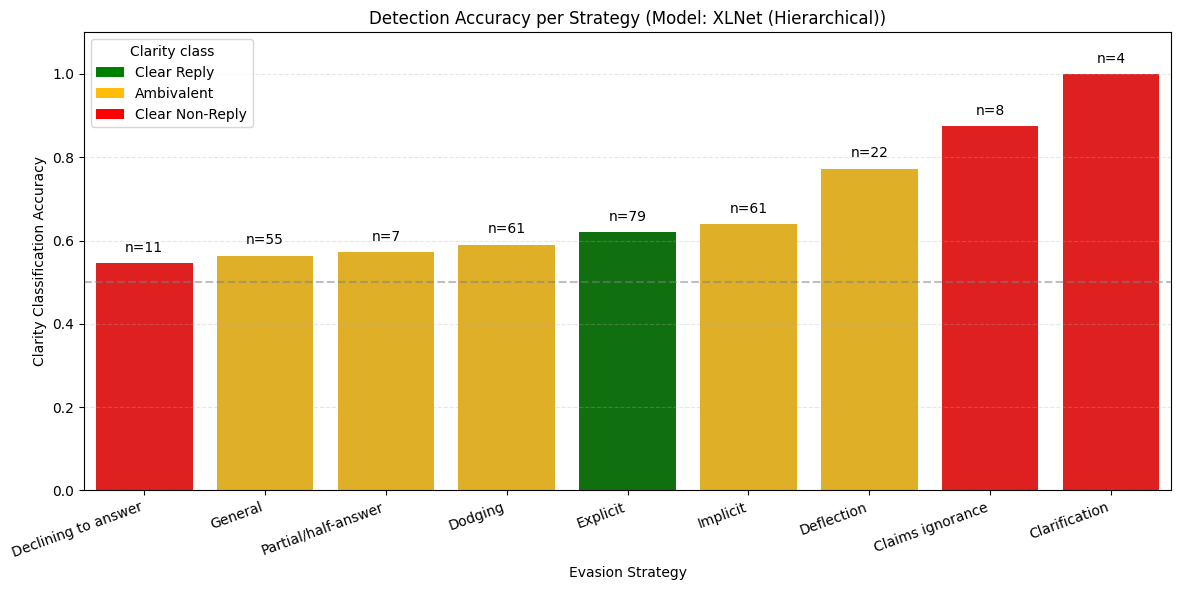

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

print("=== IMPROVED DIFFICULTY ANALYSIS (Model: XLNet Hierarchical) ===")

# --- Farben / Mapping (wie in deinem anderen Plot) ---
CLARITY_COLORS = {
    "Clear Reply": "green",
    "Ambivalent": "#febd08",
    "Clear Non-Reply": "red",
}

EVASION_TO_CLARITY = {
    "Explicit": "Clear Reply",
    "Implicit": "Ambivalent",
    "General": "Ambivalent",
    "Dodging": "Ambivalent",
    "Deflection": "Ambivalent",
    "Partial/half-answer": "Ambivalent",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Clear Non-Reply",  # so wie du es willst
}

CLARITY_ORDER = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

# 1) Datenvorbereitung (Voting für Ground Truth)
df_test_raw = pd.read_csv("../data/raw/test.csv").fillna("")
df_test_raw["voted_evasion"] = df_test_raw.apply(lambda r: resolve_evasion_vote(r), axis=1)
df_test_raw = df_test_raw.reset_index(drop=True)

# 2) Model wählen
model_name = "XLNet (Hierarchical)"

if model_name not in results:
    print(f"Model {model_name} not found in results dictionary!")
else:
    y_pred = results[model_name]["y_pred"]  # clarity IDs
    y_true = results[model_name]["y_true"]  # clarity IDs

    # Safety check: Längen müssen passen
    if len(df_test_raw) != len(y_true) or len(y_true) != len(y_pred):
        raise ValueError(
            f"Length mismatch: len(test)={len(df_test_raw)}, len(y_true)={len(y_true)}, len(y_pred)={len(y_pred)}"
        )

    # 3) Analyse-Tabelle bauen (index-sicher)
    analysis_rows = []
    for i, ev_label in enumerate(df_test_raw["voted_evasion"].tolist()):
        if ev_label not in EVASION_TO_CLARITY:
            continue

        analysis_rows.append({
            "Evasion Strategy": ev_label,
            "Clarity Class": EVASION_TO_CLARITY[ev_label],
            "Correct": int(y_pred[i] == y_true[i]),
        })

    df_analysis = pd.DataFrame(analysis_rows)

    # 4) Aggregieren
    df_grouped = (
        df_analysis
        .groupby(["Evasion Strategy", "Clarity Class"], as_index=False)
        .agg(Accuracy=("Correct", "mean"), Count=("Correct", "size"))
        .sort_values("Accuracy", ascending=True)
    )

    print(f"Analysis based on Model: {model_name}")
    print(df_grouped.to_string(index=False))

    # 5) Plotten mit "gleichen Clarity-Farben"
    bar_colors = df_grouped["Clarity Class"].map(CLARITY_COLORS).tolist()

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_grouped,
        x="Evasion Strategy",
        y="Accuracy",
        order=df_grouped["Evasion Strategy"].tolist(),
        palette=bar_colors
    )

    # Counts annotieren (kein IndexError)
    for p, count in zip(ax.patches, df_grouped["Count"].tolist()):
        ax.annotate(
            f"n={count}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center", va="bottom",
            xytext=(0, 6),
            textcoords="offset points"
        )

    # Manuelle Legend
    legend_handles = [
        Patch(facecolor=CLARITY_COLORS[c], label=c)
        for c in CLARITY_ORDER
        if c in set(df_grouped["Clarity Class"])
    ]
    ax.legend(handles=legend_handles, title="Clarity class", loc="upper left", frameon=True)

    ax.set_title(f"Detection Accuracy per Strategy (Model: {model_name})")
    ax.set_ylabel("Clarity Classification Accuracy")
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    # plt.savefig("plots/evasion_difficulty_hierarchical.png")


In [26]:
import os, glob

print("cwd:", os.getcwd())
print("files here (csv):", glob.glob("*.csv")[:50])
print("search preds_test.csv:", glob.glob("**/preds_test.csv", recursive=True)[:20])


cwd: /Users/imad.azizi/Desktop/NLPGroup29/notebooks
files here (csv): []
search preds_test.csv: []


In [25]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv("preds_test.csv")

labels9 = sorted(df["micro_true"].unique())
cm9 = confusion_matrix(df["micro_true"], df["micro_pred_k9"], labels=labels9)
cm9_df = pd.DataFrame(cm9, index=labels9, columns=labels9)

print("Top confusions (off-diagonal):")
tmp = cm9_df.copy()
for l in labels9: tmp.loc[l, l] = 0
print(tmp.stack().sort_values(ascending=False).head(15))

print("\nMicro-level report (k=9):")
print(classification_report(df["micro_true"], df["micro_pred_k9"], labels=labels9))


FileNotFoundError: [Errno 2] No such file or directory: 'preds_test.csv'

In [ ]:
map9_to_macro = {
  "Explicit": "Clear Reply",
  "Clarification": "Clear Reply",
  "Dodging": "Ambivalent",
  "Deflection": "Ambivalent",
  "Implicit": "Ambivalent",
  "General": "Ambivalent",
  "Partial/half-answer": "Ambivalent",
  "Declining to answer": "Clear Non-Reply",
  "Claims ignorance": "Clear Non-Reply",
}

map5_to_macro = {
  "Explicit": "Clear Reply",
  "Clarification": "Clear Reply",
  "Active Evasion": "Ambivalent",
  "Vague": "Ambivalent",
  "Denial": "Clear Non-Reply",
}

df["macro_pred_from_k9"] = df["micro_pred_k9"].map(map9_to_macro)
df["macro_pred_from_k5"] = df["micro_pred_k5"].map(map5_to_macro)

df["macro_err_k9"] = (df["macro_pred_from_k9"] != df["macro_true"])
df["macro_err_k5"] = (df["macro_pred_from_k5"] != df["macro_true"])

print("Macro error rate from k=9:", df["macro_err_k9"].mean())
print("Macro error rate from k=5:", df["macro_err_k5"].mean())

# Welche Micro-Verwechslungen erzeugen Macro-Fehler (k=9)?
err9 = df[df["macro_err_k9"]].copy()
err9["micro_pair"] = err9["micro_true"] + " -> " + err9["micro_pred_k9"]
print("\nMost common micro errors among macro-wrong (k=9):")
print(err9["micro_pair"].value_counts().head(15))


In [ ]:
import pandas as pd

runs = pd.read_csv("runs_by_seed.csv")  # seed, weighted_f1_k9, weighted_f1_k5
print(runs.agg(["mean","std"]))
